In [ ]:
# !unzip -q '/content/drive/MyDrive/Scifibase_skimmed.zip' -d '/content'

In [ ]:
# !pip -q install pytorch-msssim lpips

In [ ]:
import torch
import torch.nn.functional as F
import torchvision
import imageio.v3 as iio  # Use imageio v3 for modern API
import matplotlib.pyplot as plt
import numpy as np
import random
import json
import cv2
import shutil
import lpips
from google.colab import runtime
from pytorch_msssim import ssim, ms_ssim, SSIM, MS_SSIM
import os

from torch import nn
from PIL import Image
from tqdm import tqdm
from pathlib import Path
from collections import OrderedDict
from torch.utils.data import Dataset
from torchvision.utils import save_image

os.environ["OPENCV_IO_ENABLE_OPENEXR"]="1"
device = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
class SceneFilePreprocessor():
    def __init__(self, src_dir, out_dir, input_res='540p', target_res='1080p'):
        """
        Args:
            root_dir (str): Path to dataset root.
            input_res (str): Input resolution folder name.
            target_res (str): Target resolution folder name.
            split_type (str): One of 'train', 'val', or 'test'.
            split_ratios (tuple): Ratios for (train, val, test). Must sum to 1.
            seed (int): Random seed to ensure the split is reproducible.
        """
        self.root_dir = Path(src_dir)
        self.input_res = input_res
        self.target_res = target_res

        self.out_base = Path(out_dir)
        if not os.path.exists(out_dir):
            os.makedirs(out_dir)

        # --- Define the magic folder names from the dataset ---
        self.LR_COLOR_DIR = "MipBiasMinus1Jittered"
        self.LR_DEPTH_DIR = "DepthMipBiasMinus1Jittered"
        self.LR_MOTION_DIR = "MotionVectorsMipBiasMinus1Jittered"
        self.LR_CAMERA_DIR = "CameraData"
        self.HR_TARGET_DIR = "Native"

        self.scenes = []  # Store scene names instead of individual frames

        # --- Scan the file system to build the scene list ---

        lr_color_path = self.root_dir / self.input_res / self.LR_COLOR_DIR
        hr_target_path = self.root_dir / self.target_res / self.HR_TARGET_DIR

        print(f"Scanning for scenes in {lr_color_path}...")

        # 1. Collect all scene names first
        all_scenes = [p.name for p in lr_color_path.iterdir() if p.is_dir()]

        # 2. Sort to ensure consistent order before shuffling
        all_scenes.sort()

        # 4. Determine start/end indices for the requested split
        target_scenes = all_scenes

        print(f"Found {len(target_scenes)} scenes to pre-process.")

        # 5. Store scene names and verify they have target folders
        for scene_name in target_scenes:
            if (hr_target_path / scene_name).exists():
                self.scenes.append(scene_name)
            else:
                print(f"Warning: Skipping scene {scene_name}, no target folder found.")

        print(f"Validated {len(self.scenes)} scenes.")
        self.shape_file = self.out_base/"shapes.npy"
        self.shapes = np.zeros(len(self.scenes))

    def __len__(self):
        return len(self.scenes)

    def _load_packed_depth(self, path):
        # Load as a 4-channel NumPy array
        img_arr = iio.imread(path, mode='RGBA').astype(np.float64)

        # Isolate channels
        R = img_arr[..., 0]
        G = img_arr[..., 1]
        B = img_arr[..., 2]
        A = img_arr[..., 3]

        # Unpack the depth
        depth = (R / 255.0) + (G / (255.0**2)) + (B / (255.0**3)) + (A / (255.0**4))

        # Convert to a single-channel float tensor (C, H, W)
        return torch.from_numpy(depth).float().unsqueeze(0)

    def preprocess_all(self):
        for i in tqdm(range(len(self))):
            self.preprocess(i)

    def preprocess(self, idx):
        # Get the scene name
        scene_name = self.scenes[idx]

        # Base paths
        lr_base = self.root_dir / self.input_res
        lr_color_path = lr_base / self.LR_COLOR_DIR / scene_name
        out_dir = self.out_base / f"scene_{idx:05d}"
        if not os.path.exists(out_dir):
            os.makedirs(out_dir)

        # Get all frames in the scene, sorted by frame number
        frame_files = sorted(lr_color_path.glob("*.png"), key=lambda x: int(x.stem))

        # Load one file to get dimensions
        T = len(frame_files)
        H, W, C = iio.imread(frame_files[0]).shape

        # Load entire sequence
        motion_mm   = np.memmap(out_dir/"motion.dat", dtype="float32", mode="w+", shape=(T, 2, H, W))
        jitter_mm   = np.memmap(out_dir/"jitter.dat", dtype="float32", mode="w+", shape=(T, 2))
        lr_color_mm = np.memmap(out_dir/"lr_color.dat", dtype="float32", mode="w+", shape=(T, C, H, W))
        hr_color_mm = np.memmap(out_dir/"hr_color.dat", dtype="float32", mode="w+", shape=(T, 3, 2*H, 2*W))
        depth_mm    = np.memmap(out_dir/"depth.dat", dtype="float32", mode="w+", shape=(T, 1, H, W))

        for i, frame_file in enumerate(frame_files):
            frame_stem = frame_file.stem
            frame_name_png = f"{frame_stem}.png"
            frame_name_exr = f"{frame_stem}.exr"
            frame_name_json = f"{frame_stem}.json"

            # Construct all paths
            depth_path = lr_base / self.LR_DEPTH_DIR / scene_name / frame_name_png
            motion_path = lr_base / self.LR_MOTION_DIR / scene_name / frame_name_exr
            target_path = self.root_dir / self.target_res / self.HR_TARGET_DIR / scene_name / frame_name_png
            camera_data_path = lr_base / self.LR_CAMERA_DIR / scene_name / frame_name_json

            # Load all data
            lr_color = torch.from_numpy(iio.imread(frame_file)).permute(2, 0, 1).float() / 255.0
            target = torch.from_numpy(iio.imread(target_path, mode="RGB")).permute(2, 0, 1).float() / 255.0
            depth = self._load_packed_depth(depth_path)

            motion_vecs = cv2.imread(str(motion_path), cv2.IMREAD_UNCHANGED)[:,:,:3]
            motion = torch.from_numpy(motion_vecs[..., 1:]).permute(2, 0, 1).float()
            motion = motion[[1,0], :, :]

            # Load camera data (jitter)
            with open(camera_data_path, 'r') as f:
                camera_data = json.load(f)
            jitter = torch.tensor([camera_data['jitter_offset']['x'], camera_data['jitter_offset']['y']], dtype=torch.float32)

            motion_mm[i] = motion.numpy()
            lr_color_mm[i] = lr_color.numpy()
            hr_color_mm[i] = target.numpy()
            depth_mm[i] = depth.numpy()
            jitter_mm[i] = jitter.numpy()

        motion_mm.flush()
        lr_color_mm.flush()
        hr_color_mm.flush()
        depth_mm.flush()
        jitter_mm.flush()

        self.shapes[idx] = T
        np.save(self.shape_file, self.shapes)

        return out_dir

In [ ]:
if not os.path.exists("/content/QRISP_PP") or not os.listdir("/content/QRISP_PP"):
  preprocessor = SceneFilePreprocessor(
      "/content/QRISP/ScifiBase",
      "/content/QRISP_PP"
  )

  preprocessor.preprocess_all()

In [ ]:
class TemporalUpscaleDataset(Dataset):

    def __init__(self, root_dir, lr_dimensions=(4, 540, 960),
                 split_type='train', utilization=1, split_ratios=(0.7, 0.15, 0.15), seed=42, seq_len=14, lr_crop_size=132):
        """
        Args:
            root_dir (str): Path to dataset root.
            input_res (str): Input resolution folder name.
            target_res (str): Target resolution folder name.
            split_type (str): One of 'train', 'val', or 'test'.
            split_ratios (tuple): Ratios for (train, val, test). Must sum to 1.
            seed (int): Random seed to ensure the split is reproducible.
        """
        self.root_dir = Path(root_dir)
        self.input_res = list(lr_dimensions)
        self.seq_len = seq_len
        self.lr_crop_size = lr_crop_size

        self.shapes = np.load(self.root_dir/"shapes.npy").astype(int)

        # Validate split type
        assert split_type in ['train', 'val', 'test'], "split_type must be 'train', 'val', or 'test'"

        # --- Define the magic folder names from the dataset ---
        self.LR_COLOR_FILE = "lr_color.dat"
        self.LR_DEPTH_FILE = "depth.dat"
        self.LR_MOTION_FILE = "motion.dat"
        self.LR_CAMERA_FILE = "jitter.dat"
        self.HR_TARGET_FILE = "hr_color.dat"

        self.scenes = []  # Store scene names instead of individual frames

        # --- Scan the file system to build the scene list ---

        lr_color_path = self.root_dir

        print(f"Scanning for scenes in {lr_color_path}...")

        # 1. Collect all scene names first
        all_scenes = np.array(sorted([p.name for p in lr_color_path.iterdir() if p.is_dir()]))

        # 3. Shuffle deterministically
        rng = random.Random(seed)
        indices = np.arange(len(all_scenes), dtype=int)
        rng.shuffle(indices)
        all_scenes = all_scenes[indices]
        self.shapes = self.shapes[indices]

        # 4. Determine start/end indices for the requested split
        total_scenes = len(all_scenes)
        train_end = int(total_scenes * split_ratios[0])
        val_start = train_end
        val_end = train_end + max(int(total_scenes * split_ratios[1] * utilization), 1)
        train_end = max(int(total_scenes * split_ratios[0] * utilization), 1)

        if split_type == 'train':
            target_scenes = all_scenes[:train_end]
        elif split_type == 'val':
            target_scenes = all_scenes[val_start:val_end]
        elif split_type == 'test':
            target_scenes = all_scenes[val_end:]

        self.scenes = target_scenes
        print(f"Split '{split_type}': Assigned {len(target_scenes)} scenes out of {total_scenes}.")

    def __len__(self):
        return len(self.scenes)

    def __getitem__(self, idx):
        T = self.shapes[idx]
        C, H, W = self.input_res

        # --- Temporal Cropping ---
        if T > self.seq_len: T0 = random.randint(0, T - self.seq_len)
        else: T0 = 0
        T1 = T0 + self.seq_len

        # --- Spatial Cropping ---
        crop_y = random.randint(0, H - self.lr_crop_size)
        crop_x = random.randint(0, W - self.lr_crop_size)
        hr_crop_y, hr_crop_x = crop_y * 2, crop_x * 2
        hr_crop_size = self.lr_crop_size * 2

        # Open memmaps
        scene_root = self.root_dir / self.scenes[idx]
        depth_mm    = np.memmap(scene_root / self.LR_DEPTH_FILE, dtype="float32", mode="r", shape=(T, 1, H, W))
        motion_mm   = np.memmap(scene_root / self.LR_MOTION_FILE, dtype="float32", mode="r", shape=(T, 2, H, W))
        lr_color_mm = np.memmap(scene_root / self.LR_COLOR_FILE, dtype="float32", mode="r", shape=(T, C, H, W))
        hr_color_mm = np.memmap(scene_root / self.HR_TARGET_FILE, dtype="float32", mode="r", shape=(T, 3, 2*H, 2*W))
        jitter_mm   = np.memmap(scene_root / self.LR_CAMERA_FILE, dtype="float32", mode="r", shape=(T, 2))

        return {
            "jitter": torch.from_numpy(jitter_mm[T0:T1].copy()),
            "motion": torch.from_numpy(motion_mm[T0:T1, :, crop_y:crop_y+self.lr_crop_size, crop_x:crop_x+self.lr_crop_size].copy()),
            "lr_color": torch.from_numpy(lr_color_mm[T0:T1, :, crop_y:crop_y+self.lr_crop_size, crop_x:crop_x+self.lr_crop_size].copy()),
            "hr_color": torch.from_numpy(hr_color_mm[T0:T1, :, hr_crop_y:hr_crop_y+hr_crop_size, hr_crop_x:hr_crop_x+hr_crop_size].copy()),
            "depth": torch.from_numpy(depth_mm[T0:T1, :, crop_y:crop_y+self.lr_crop_size, crop_x:crop_x+self.lr_crop_size].copy()),
        }

In [ ]:
class JitterConditionedConv(nn.Module):
    def __init__(self, in_ch, out_ch, hidden=2048):
        super().__init__()

        self.in_ch = in_ch
        self.out_ch = out_ch

        # MLP predicts per-sample 3x3 kernels
        self.mlp = nn.Sequential(
            nn.Linear(2, hidden),
            nn.ReLU(inplace=True),
            nn.Linear(hidden, hidden),
            nn.ReLU(inplace=True),
            nn.Linear(hidden, hidden),
            nn.ReLU(inplace=True),
            nn.Linear(hidden, hidden),
            nn.ReLU(inplace=True),
            nn.Linear(hidden, hidden),
            nn.ReLU(inplace=True),
            nn.Linear(hidden, hidden),
            nn.ReLU(inplace=True),
            nn.Linear(hidden, hidden),
            nn.ReLU(inplace=True),
            nn.Linear(hidden, hidden),
            nn.ReLU(inplace=True),
            nn.Linear(hidden, out_ch * in_ch * 3 * 3),
        )

        self.bias = nn.Parameter(torch.zeros(out_ch))

    def forward(self, input):
        """
        x:      (B, Cin, H, W)
        jitter: (B, 2)
        """
        x, jitter = input
        B, Cin, H, W = x.shape
        assert Cin == self.in_ch

        # Predict kernels
        w = self.mlp(jitter)                      # (B, Cout*Cin*3*3)
        w = w.view(B, self.out_ch, Cin, 3, 3)     # (B, Cout, Cin, 3, 3)

        # Grouped convolution for per-sample kernels
        x = x.view(1, B * Cin, H, W)
        w = w.view(B * self.out_ch, Cin, 3, 3)

        y = F.conv2d(
            x,
            w,
            bias=self.bias.repeat(B),
            padding=1,
            groups=B
        )

        y = y.view(B, self.out_ch, H, W)
        return y


In [ ]:
import torch
import gc
import psutil
import os

def inspect_cpu_memory():
    print("\n--- CPU MEMORY SNAPSHOT ---")

    # 1. Check Total System RAM Usage
    process = psutil.Process(os.getpid())
    print(f"Total RAM Used by Process: {process.memory_info().rss / 1024**3:.2f} GB")

    # 2. Inspect PyTorch Tensors on CPU
    tensors = []
    # gc.get_objects() returns a list of all objects tracked by the garbage collector
    for obj in gc.get_objects():
        try:
            # Check if object is a tensor
            if torch.is_tensor(obj) or (hasattr(obj, 'data') and torch.is_tensor(obj.data)):
                t = obj if torch.is_tensor(obj) else obj.data

                # We only care about CPU tensors now
                if not t.is_cuda:
                    # Calculate size in MB
                    size_mb = t.element_size() * t.nelement() / 1024**2
                    if size_mb > 10: # Only list tensors > 10MB
                        tensors.append((list(t.size()), size_mb, type(obj)))
        except:
            pass # Skip objects that cause errors during inspection

    # Sort by size (largest first)
    tensors.sort(key=lambda x: x[1], reverse=True)

    print(f"Top 10 Largest CPU Tensors:")
    size_sum = 0
    for shape, size, obj_type in tensors:
        print(f"  Shape: {shape} | Size: {size:.1f} MB | Type: {obj_type}")
        size_sum += size
    print(f"Size: {size_sum:.1f} MB")


    print(f"Count of Tensors > 10MB: {len(tensors)}")

In [ ]:
class TemporalUpscaleUNet(nn.Module):
  def __init__(self, n_recurrent_features=5, n_hidden_features=16, n_convolutions=5, mlp_size=2048):
    # assert high_res[1] == low_res[1]*2 and high_res[0] == low_res[0]*2

    super().__init__()
    # self.high_res = high_res
    # self.low_res = low_res
    self.n_recurrent_features = n_recurrent_features

    self.initial_convolution = JitterConditionedConv((4*(3+n_recurrent_features)+5), n_hidden_features, mlp_size)

    self.convolution_sequence = torch.nn.Sequential(OrderedDict([
        (str(f"Conv{i//2}"), torch.nn.Conv2d(n_hidden_features, n_hidden_features, kernel_size=3, padding=1)) if i%2==0
        else (str(f"ReLU{i//2}"), nn.ReLU())
        for i in range(2*n_convolutions)
    ]))

    self.hidden_state_head = torch.nn.Sequential(
      JitterConditionedConv(n_hidden_features, n_recurrent_features*4, mlp_size),
      nn.PixelShuffle(2)
    )

    self.candidate_hr_head = torch.nn.Sequential(
      JitterConditionedConv(n_hidden_features, 12, mlp_size),
      nn.ReLU(),
      nn.PixelShuffle(2)
    )

    self.blend_mask_head = torch.nn.Sequential(
      JitterConditionedConv(n_hidden_features, 4, mlp_size),
      nn.Sigmoid(),
      nn.PixelShuffle(2)
    )

  def mv_dilation(
    self,
    mv: torch.Tensor,
    depth: torch.Tensor,
    out_H: int,
    out_W: int,
    block_size: int = 6
):
    """
    Depth-informed motion vector dilation.

    Args:
        mv:     (B, 2, H, W) motion vectors
        depth:  (B, 1, H, W) depth (smaller = closer)
        block_size: block size in pixels (e.g. 8)

    Returns:
        dilated_mv: (B, 2, H, W)
    """

    B, _, H, W = mv.shape
    assert depth.shape == (B, 1, H, W)
    assert H % block_size == 0 and W % block_size == 0

    # Reshape into blocks
    h_blocks = H // block_size
    w_blocks = W // block_size

    mv_flat = (mv.contiguous()
        .view(B, 2, h_blocks, block_size, w_blocks, block_size)
        .permute(0, 1, 2, 4, 3, 5)
        .flatten(start_dim=4)) # (B, 2, hb, wb, block_size**2)

    depth_flat = (depth.contiguous()
        .view(B, 1, h_blocks, block_size, w_blocks, block_size)
        .permute(0, 1, 2, 4, 3, 5)
        .flatten(start_dim=4)) # (B, 1, hb, wb, block_size**2)

    # Find index of minimum depth per block
    min_idx = depth_flat.argmin(dim=-1).unsqueeze(-1) # (B,1,hb,wb,1)
    min_idx = min_idx.expand(-1, 2, -1, -1, -1)       # Prepare gather indices

    # Gather frontmost MV
    mv_front = torch.gather(
        mv_flat,
        dim=-1,
        index=min_idx
    )  # (B,2,hb,wb,1)

    # Broadcast back to full resolution
    # Expand inside block (restore 2D block structure)
    mv_block = mv_front.expand(-1, -1, -1, -1, block_size * block_size)

    mv_block = mv_block.view(
        B, 2, h_blocks, w_blocks, block_size, block_size
    )

    # Reconstruct full resolution
    dilated_mv = (
        mv_block
        .permute(0, 1, 2, 4, 3, 5)   # (B,2,hb,block,hb,block)
        .reshape(B, 2, H, W)
    )

    # Upscale 2x if needed
    if out_H != H or out_W != W:
        dilated_mv = torch.nn.functional.interpolate(
            dilated_mv,
            size=(out_H, out_W),
            mode="nearest"
        )

    return dilated_mv

  def warp_prev_hr(self, prev_hr, mv_dilated):
    """
    prev_hr:    (B, C, H, W)
    mv_dilated: (B, 2, H, W)  pixel offsets (dx, dy)
                dx > 0 means sample from the right in prev frame
    """

    B, C, H, W = prev_hr.shape
    device = prev_hr.device

    # Base pixel grid (x, y)
    y, x = torch.meshgrid(
        torch.arange(H),
        torch.arange(W),
        indexing="ij"
    )
    base_grid = torch.stack((x, y), dim=-1)          # (H, W, 2)
    base_grid = base_grid.unsqueeze(0).float()       # (1, H, W, 2)
    base_grid = base_grid.to(mv_dilated.device)

    # Add motion vectors
    # print(base_grid.shape, mv_dilated.shape)
    sample_pos = base_grid - mv_dilated.permute(0, 2, 3, 1)

    # TODO: Verify whether this normalization is correct
    # Normalize to [-1, 1]
    sample_pos[..., 0] = 2.0 * sample_pos[..., 0] / (W - 1) - 1.0
    sample_pos[..., 1] = 2.0 * sample_pos[..., 1] / (H - 1) - 1.0

    # Bilinear sampling
    warped = F.grid_sample(
        prev_hr,
        sample_pos,
        mode="bilinear",
        padding_mode="zeros",
        align_corners=True
    )

    sliced = nn.functional.pixel_unshuffle(warped, 2)

    return sliced

  def forward(self, batch_dict, h0=None, prev_jitter=None):
    device = batch_dict["lr_color"].device
    B, T, C, H, W = batch_dict["lr_color"].shape

    outputs = []
    prev_features = torch.zeros((B, self.n_recurrent_features+3, H*2, W*2)).to(device) if h0 is None else h0
    prev_jitter = torch.zeros((B, 2, 1, 1)).to(device) if prev_jitter is None else prev_jitter

    for i in range(T):
      lr = batch_dict["lr_color"][:, i, :, :, :]   # [B, C, H, W]
      depth = batch_dict["depth"][:, i, :, :, :]   # [B, 1, H, W]
      mv = batch_dict["motion"][:, i, :, :, :]     # [B, 2, H, W]
      jitter = batch_dict["jitter"][:, i, :]       # [B, 2]

      # Transform motion vectors to pixel space
      mv = mv*(torch.Tensor([[-1920, 1080]]).unsqueeze(-1).unsqueeze(-1).to(device))

      # Preprocessing previous frame features to align them to current frame
      # print(depth.shape, lr.shape, prev_features.shape)
      jitter = jitter.reshape(prev_jitter.shape)
      mv = mv + prev_jitter - jitter
      dilated_mv = self.mv_dilation(mv, depth, H*2, W*2)
      warped_prev = self.warp_prev_hr(prev_features, dilated_mv)

      # print(depth.shape, lr.shape, warped_prev.shape)
      x = torch.cat((depth, lr, warped_prev), dim=1)
      # print(x.shape)
      x = self.initial_convolution((x, jitter.reshape(B,2)))
      # print(x.shape)
      x = self.convolution_sequence(x)
      # print(x.shape)
      out_features = self.hidden_state_head((x, jitter.reshape(B,2)))
      hr_candidate = self.candidate_hr_head((x, jitter.reshape(B,2)))
      hr_candidate = hr_candidate.clamp(0.0, 1.0)
      blend_mask = self.blend_mask_head((x, jitter.reshape(B,2)))

      prev_frame_unshuffled = F.pixel_shuffle(warped_prev[:, :12], 2)
      # print(hr_candidate.shape, prev_frame_unshuffled.shape, blend_mask.shape)
      out_frame = blend_mask*hr_candidate + (1-blend_mask)*prev_frame_unshuffled

      outputs.append(out_frame)

      # === MEMORY INSPECTOR START ===
      # Run this check every 5 frames
      # if i % 5 == 0:
      #     inspect_cpu_memory()
      # === MEMORY INSPECTOR END ===

      # print(x.shape, out_frame.shape, out_features.shape, prev_features.shape)
      prev_features = torch.cat([out_frame, out_features], dim=1)
      prev_jitter = jitter

    return torch.stack(outputs, dim=1), prev_features, prev_jitter

In [ ]:
def psnr(pred, gt):
    mse = torch.mean((pred - gt) ** 2)
    return 10 * torch.log10(1.0 / mse)

def mse(pred, gt):
    mse = torch.mean((pred - gt) ** 2)
    return mse

# def lpips(pred, gt):
#   return LPIPS_MODEL(net='vgg')(pred, gt)

In [ ]:
# Load the dataset with a 70-15-15 split
train_ds = TemporalUpscaleDataset(root_dir="/content/QRISP_PP", split_type='train', utilization=1, seq_len=14, lr_crop_size=264)
val_ds = TemporalUpscaleDataset(root_dir="/content/QRISP_PP", split_type='val', utilization=0.5, seq_len=7, lr_crop_size=540)
# test_ds = TemporalUpscaleDataset(root_dir="/content/QRISP/ScifiBase", split_type='test')

batch_size=7
train_loader = torch.utils.data.DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True, prefetch_factor=4, persistent_workers=True)
val_loader = torch.utils.data.DataLoader(val_ds, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True, prefetch_factor=4, persistent_workers=True)
# test_loader = torch.utils.data.DataLoader(test_ds, batch_size=1, shuffle=True, num_workers=2, pin_memory=True, prefetch_factor=2, persistent_workers=True)

Scanning for scenes in /content/QRISP_PP...
Split 'train': Assigned 28 scenes out of 41.
Scanning for scenes in /content/QRISP_PP...
Split 'val': Assigned 3 scenes out of 41.


In [ ]:
def render_input_sample(sample):
  T,C,H,W = sample["lr_color"].shape
  fig, axes = plt.subplot_mosaic("AB;CD;EF", figsize=(4.8*2, 2.7*2*3))
  axes["A"].imshow(sample["motion"][0,0].abs())
  axes["A"].set_title("X-MV")
  axes["B"].imshow(sample["motion"][0,1].abs())
  axes["B"].set_title("Y-MV")
  axes["C"].imshow(sample["lr_color"][0, 0:3].permute(1,2,0))
  axes["C"].set_title("Input")
  axes["D"].imshow(1-(sample["depth"][0,0].resize(H,W)**0.001), cmap="gray")
  axes["D"].set_title("Depth (inverted)")
  axes["E"].imshow(sample["hr_color"][0, 0:3].permute(1,2,0))
  interpolated = cv2.resize(sample["lr_color"][0].permute(1,2,0).numpy(), (W*2, H*2), interpolation=cv2.INTER_CUBIC)
  axes["E"].set_title("Ground Truth")
  axes["F"].imshow(interpolated)
  axes["F"].set_title("Bicubic")

  # plt.tight_layout()
  plt.show()

In [ ]:
# test_scene = train_ds[2]

In [ ]:
# render_input_sample(test_scene)

In [ ]:
class CharbonnierLoss(nn.Module):
    def __init__(self, eps=1e-6):
        super(CharbonnierLoss, self).__init__()
        self.eps = eps

    def forward(self, pred, target):
        diff = pred - target
        loss = torch.sqrt(diff * diff + self.eps)
        return torch.mean(loss)

def ssim_loss(pred, target):
    """
    Basic SSIM implementation for training.
    Ideally, use 'torchmetrics.functional.ssim' for a robust version.
    """
    # Create a simple 11x11 gaussian window (or just use local statistics)
    C1 = 0.01 ** 2
    C2 = 0.03 ** 2

    mu_x = nn.functional.avg_pool2d(pred, 3, 1, 1)
    mu_y = nn.functional.avg_pool2d(target, 3, 1, 1)

    sigma_x = nn.functional.avg_pool2d(pred**2, 3, 1, 1) - mu_x**2
    sigma_y = nn.functional.avg_pool2d(target**2, 3, 1, 1) - mu_y**2
    sigma_xy = nn.functional.avg_pool2d(pred * target, 3, 1, 1) - mu_x * mu_y

    ssim_map = ((2 * mu_x * mu_y + C1) * (2 * sigma_xy + C2)) / \
               ((mu_x**2 + mu_y**2 + C1) * (sigma_x + sigma_y + C2))

    return 1 - ssim_map.mean()

charb_fn = CharbonnierLoss().to(device)

In [ ]:
def test_warping(scene):
  T,C,H,W = scene["lr_color"].shape
  prev_hr = scene["hr_color"][1].unsqueeze(0)
  current_hr = scene["hr_color"][0].unsqueeze(0)
  mv = scene["motion"][0].unsqueeze(0)
  depth = scene["depth"][0].unsqueeze(0)

  mv = mv*(torch.Tensor([[-1920, 1080]]).unsqueeze(-1).unsqueeze(-1))

  mv_dilated = model.mv_dilation(
      mv,
      depth,
      H*2,
      W*2,
      block_size = 6
  )

  print(mv_dilated.max(), mv_dilated.min())

  warped_hr = model.warp_prev_hr(prev_hr, mv_dilated)
  warped_hr = torch.pixel_shuffle(warped_hr, 2)

  mv_dilated[0] -= mv_dilated[0].min()
  mv[0] -= mv[0].min()

  fig, axes = plt.subplot_mosaic("CDE", figsize=(9.6*1.5, 5.4))
  axes["C"].imshow(prev_hr[0].permute(1,2,0))
  axes["C"].set_title("Previous")
  # axes["B"].imshow(mv_dilated[0][1])
  # axes["B"].set_title("MV-X-dilated")
  # axes["A"].imshow(mv[0][1])
  # axes["A"].set_title("MV-X")
  axes["D"].imshow(warped_hr[0].permute(1,2,0))
  axes["D"].set_title("Warped")
  axes["E"].imshow(current_hr[0].permute(1,2,0))
  axes["E"].set_title("Actual")
  plt.show()


In [ ]:
# test_warping(test_scene)

In [ ]:
def save_debug_image(batch_dict, outputs, file_name):
  os.makedirs("val_debug", exist_ok=True)

  # Save first few frames only (avoid dumping entire sequence)
  num_frames_to_save = min(14, len(outputs))

  pred = outputs[0, :num_frames_to_save]
  target = batch_dict["hr_color"][0, :num_frames_to_save].detach()
  lr = batch_dict["lr_color"][0, :num_frames_to_save].detach()

  if lr.shape[-2:] != pred.shape[-2:]:
      lr_up = torch.nn.functional.interpolate(
          lr,
          size=pred.shape[-2:],
          mode="bilinear",
          align_corners=False
      )
  else:
      lr_up = lr

  diff = torch.abs(pred - target)

  # LR | Pred | GT | Diff  (horizontal)
  frame_strips = torch.cat([lr_up[:, :3], pred, target, diff], dim=-1)

  # Concatenate frames horizontally into one large image
  T, C, H, W = frame_strips.shape
  full_strip = frame_strips.permute(1, 0, 2, 3).reshape(C, H*T, W)
  full_strip = full_strip.cpu()

  save_image(
      full_strip,
      "val_debug/" + file_name
  )

In [ ]:
model = TemporalUpscaleUNet(
    # high_res=(1080,1920),
    # low_res=(540, 960),
    n_recurrent_features=10, # 10
    n_hidden_features=48, # 32
    n_convolutions=3, # 3
    mlp_size=512 # 256
).to(device)
# model = torch.compile(model)

optimizer = torch.optim.Adam(model.parameters(), lr=2*1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
l1_loss = nn.L1Loss()
lpips_alex = lpips.LPIPS(net='alex').to(device)
ssim_fn = SSIM(data_range=1, size_average=True, channel=3)
def loss_fn(p,g):
  B,T,C,H,W = p.shape
  loss = (l1_loss(p,g) +
          0.1*lpips_alex(p.reshape(B*T, C, H, W),g.reshape(B*T, C, H, W)).mean() +
          0.2*(1-ssim_fn(p.reshape(B*T, C, H, W),g.reshape(B*T, C, H, W))))
  return loss

train_loss_history = []
train_psnr_history = []
val_loss_history = []
val_psnr_history = []

param_size = 0
for param in model.parameters():
    param_size += param.nelement() * param.element_size()
buffer_size = 0
for buffer in model.buffers():
    buffer_size += buffer.nelement() * buffer.element_size()

size_all_mb = (param_size + buffer_size) / 1024**2
print('model size: {:.3f}MB'.format(size_all_mb))

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
model size: 123.846MB


In [ ]:
# model.load_state_dict(torch.load("/content/model.pth", weights_only=True))
# model.load_state_dict(torch.load("/content/drive/MyDrive/temporal_sr_backup/model.pth", weights_only=True))

In [ ]:
import math

num_epochs = 100
chunk_size = 7
flag = False

for epoch in range(num_epochs):
    model.train()
    total_loss = 0.0
    total_mse = 0.0
    total_frames = 0

    for batch_dict in tqdm(train_loader):
        # Move sequence data to device
        batch_dict["lr_color"] = batch_dict["lr_color"].to(device, non_blocking=True)
        batch_dict["hr_color"] = batch_dict["hr_color"].to(device, non_blocking=True)
        batch_dict["jitter"] = batch_dict["jitter"].to(device, non_blocking=True)
        batch_dict["motion"] = batch_dict["motion"].to(device, non_blocking=True)
        batch_dict["depth"] = batch_dict["depth"].to(device, non_blocking=True)

        prev_features = None
        prev_jitter = None
        T = batch_dict["lr_color"].shape[1]

        for chunk_start in range(0, T, chunk_size):
          chunk_end = min(chunk_start + chunk_size, T)
          if chunk_end - chunk_start < 5: continue
          chunk_dict = {
              "lr_color": batch_dict["lr_color"][:, chunk_start:chunk_end],
              "hr_color": batch_dict["hr_color"][:, chunk_start:chunk_end],
              "jitter": batch_dict["jitter"][:, chunk_start:chunk_end],
              "motion": batch_dict["motion"][:, chunk_start:chunk_end],
              "depth": batch_dict["depth"][:, chunk_start:chunk_end],
          }

          # Forward pass
          outputs, prev_features, prev_jitter = model(chunk_dict, prev_features, prev_jitter)

          if (epoch==num_epochs-1) and not flag:
            save_debug_image(chunk_dict, outputs, f"epoch_last_train.png")
            flag = True

          # Compute loss over all frames in sequence
          loss = loss_fn(outputs, chunk_dict["hr_color"])
          mse_value = mse(outputs, chunk_dict["hr_color"]).detach().item()

          # Backward pass
          optimizer.zero_grad()
          loss.backward()
          torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
          optimizer.step()

          prev_jitter = prev_jitter.detach()
          prev_features = prev_features.detach()

          total_loss += loss.detach().item() * outputs.shape[0] * outputs.shape[1]
          total_mse += mse_value * outputs.shape[0] * outputs.shape[1]
          total_frames += outputs.shape[0] * outputs.shape[1]

          del outputs, loss, mse_value
          torch.cuda.empty_cache()

    avg_loss = total_loss / (total_frames)
    avg_psnr =  10 * math.log10(total_frames / total_mse)

    scheduler.step()
    print(f"Epoch {epoch+1}/{num_epochs}: Loss={avg_loss:.4f}, PSNR={avg_psnr:.2f}dB")
    train_loss_history.append(avg_loss)
    train_psnr_history.append(avg_psnr)

    torch.save(model.state_dict(), "/content/model.pth")

    # Validation
    if (epoch) % 10 == 0:
        model.eval()
        val_loss = 0.0
        val_mse = 0.0
        val_frames = 0

        with torch.no_grad():
            saved_first_val = False
            for batch_dict in tqdm(val_loader):
                # Move sequence data to device
                batch_dict["lr_color"] = batch_dict["lr_color"].to(device, non_blocking=True)
                batch_dict["hr_color"] = batch_dict["hr_color"].to(device, non_blocking=True)
                batch_dict["jitter"] = batch_dict["jitter"].to(device, non_blocking=True)
                batch_dict["motion"] = batch_dict["motion"].to(device, non_blocking=True)
                batch_dict["depth"] = batch_dict["depth"].to(device, non_blocking=True)

                # Forward pass
                outputs, _, _ = model(batch_dict, None, None)

                if not saved_first_val:
                  save_debug_image(batch_dict, outputs, f"epoch_{epoch+1}_val.png")
                  saved_first_val = True

                loss = loss_fn(outputs, batch_dict["hr_color"]).item()
                mse_value = mse(outputs, batch_dict["hr_color"]).item()

                val_loss += loss * outputs.shape[0] * outputs.shape[1]
                val_mse += mse_value * outputs.shape[0] * outputs.shape[1]
                val_frames += outputs.shape[0] * outputs.shape[1]

        avg_val_loss = val_loss / val_frames
        avg_val_psnr = 10 * math.log10(1.0 / (val_mse / val_frames))
        print(f"Val: Loss={avg_val_loss:.4f}, PSNR={avg_val_psnr:.2f}dB")
        val_loss_history.append(avg_val_loss)
        val_psnr_history.append(avg_val_psnr)
    else:
        val_loss_history.append(val_loss_history[-1])
        val_psnr_history.append(val_psnr_history[-1])

100%|██████████| 4/4 [00:45<00:00, 11.36s/it]


Epoch 1/100: Loss=0.3867, PSNR=12.53dB


100%|██████████| 1/1 [00:09<00:00,  9.88s/it]


Val: Loss=0.4379, PSNR=10.12dB


100%|██████████| 4/4 [00:49<00:00, 12.29s/it]


...

Epoch 98/100: Loss=0.1137, PSNR=22.75dB


100%|██████████| 4/4 [00:46<00:00, 11.75s/it]


Epoch 99/100: Loss=0.1094, PSNR=22.74dB


100%|██████████| 4/4 [00:47<00:00, 11.95s/it]


Epoch 100/100: Loss=0.1048, PSNR=23.45dB


In [ ]:
drive_path = "/content/drive/MyDrive/temporal_sr_backup/apr_18_2/"
os.makedirs(drive_path, exist_ok=True)

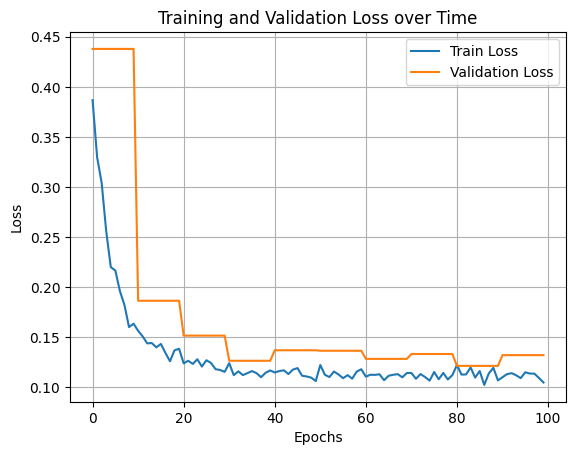

In [ ]:
plt.plot(train_loss_history, label='Train Loss')
plt.plot(val_loss_history, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss over Time')
plt.legend()
plt.grid(True)
plt.savefig(f"{drive_path}/Loss.png")
plt.show()

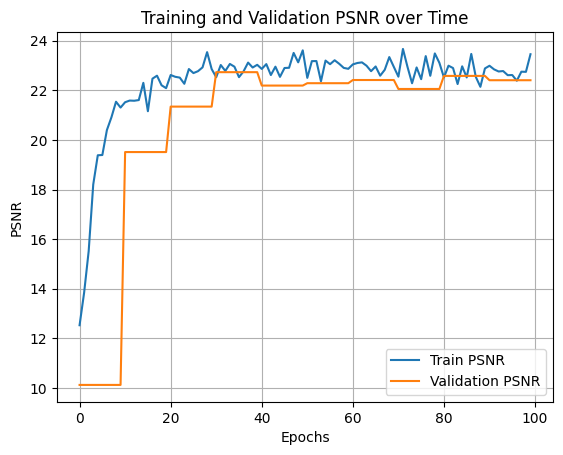

In [ ]:
plt.plot(train_psnr_history, label='Train PSNR')
plt.plot(val_psnr_history, label='Validation PSNR')
plt.xlabel('Epochs')
plt.ylabel('PSNR')
plt.title('Training and Validation PSNR over Time')
plt.legend()
plt.grid(True)
plt.savefig(f"{drive_path}/PSNR.png")
plt.show()

In [ ]:
# for i, batch_dict in enumerate(train_loader):
#   print(i, batch_dict["lr_color"].shape)

In [ ]:
shutil.copy("model.pth", os.path.join(drive_path, "model.pth"))

shutil.copytree(
    "val_debug",
    os.path.join(drive_path, "val_debug"),
    dirs_exist_ok=True
)

runtime.unassign()